# Imports

In [144]:
import importlib.util
import re

import matplotlib.pyplot as plt
import nltk
import pandas as pd
from IPython.display import display
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split

# Проверяем корпус WordNet, который нужен для английской лемматизации
try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)

# 1. Загружаем и разбиваем данные

In [145]:
true_news_df = pd.read_csv(
    r"..\data\misinformation_n_fake_news\DataSet_Misinfo_TRUE.csv", index_col=0
)
true_news_df

,text
0,The head of a conservative Republican faction ...
1,Transgender people will be allowed for the fir...
2,The special counsel investigation of links bet...
3,Trump campaign adviser George Papadopoulos tol...
4,President Donald Trump called on the U.S. Post...
...,...
34970,Most conservatives who oppose marriage equalit...
34971,The freshman senator from Georgia quoted scrip...
34972,The State Department told the Republican Natio...
34973,"ADDIS ABABA, Ethiopia —President Obama convene..."


In [146]:
fake_news_df = pd.read_csv(
    r"..\data\misinformation_n_fake_news\DataSet_Misinfo_FAKE.csv", index_col=0
)
fake_news_df

,text
0,Donald Trump just couldn t wish all Americans ...
1,House Intelligence Committee Chairman Devin Nu...
2,"On Friday, it was revealed that former Milwauk..."
3,"On Christmas day, Donald Trump announced that ..."
4,Pope Francis used his annual Christmas Day mes...
...,...
44422,The USA wants to divide Syria.\r\n\r\nGreat Br...
44423,The Ukrainian coup d'etat cost the US nothing ...
44424,The European Parliament falsifies history by d...
44425,The European Parliament falsifies history by d...


Разделяем выборку на обучающую (Train) и тестовую (Test) в соотношении 80/20 с применением стратификации по целевому классу.

In [147]:
# Добавляем метки классов
true_news_df["target"] = 1
fake_news_df["target"] = 0

# Объединяем true/fake новости в одну выборку
news_df = pd.concat([true_news_df, fake_news_df], ignore_index=True)

# Делим на Train/Test 80/20 со стратификацией по целевому классу
train_df, test_df = train_test_split(
    news_df,
    test_size=0.2,
    random_state=42,
    stratify=news_df["target"],
)

# Проверяем пропорции классов
print(train_df["target"].value_counts(normalize=True))
print(test_df["target"].value_counts(normalize=True))

target
0    0.555117
1    0.444883
Name: proportion, dtype: float64
target
0    0.555139
1    0.444861
Name: proportion, dtype: float64


# 2. Исследуем структуру данных на обучающей выборке

Cчитаем общее число документов, среднюю длину текстов в словах и символах на обучающей выборке.

In [148]:
docs_count = len(train_df)
words_count = train_df["text"].str.split().str.len()
chars_count = train_df["text"].str.len()

print("Число документов:", docs_count)
print("Средняя длина текстов:", words_count.mean())
print("Средняя длина символов:", chars_count.mean())

Число документов: 62893
Средняя длина текстов: 478.4676475266423
Средняя длина символов: 2891.4709241291553


In [149]:
# Количество NaN, None и pd.NA по колонкам.
nan_mask = train_df.isna()
print("Проверка есть ли пустые значения:\n", nan_mask.sum(), "\n")

# Проверка пустых или состоящих только из пробелов строк.
blank_strings_by_column = train_df.astype(str).apply(lambda col: col.str.strip().eq("").sum())
print("Проверка есть ли пустые строки:\n", blank_strings_by_column)

Проверка есть ли пустые значения:
 text      23
target     0
dtype: int64 

Проверка есть ли пустые строки:
 text      0
target    0
dtype: int64


In [162]:
# Удаляем пустые значения
processed_train_df = train_df.dropna()

# Пересчитываем метрики
docs_count = len(processed_train_df)
words_count = processed_train_df["text"].str.split().str.len()
chars_count = processed_train_df["text"].str.len()

print("Число документов:", docs_count)
print("Средняя длина текстов:", words_count.mean())
print("Средняя длина символов:", chars_count.mean())

Число документов: 62870
Средняя длина текстов: 478.4676475266423
Средняя длина символов: 2891.4709241291553


Графики распределения длин текстов и частоты топ-30 стоп-слов.

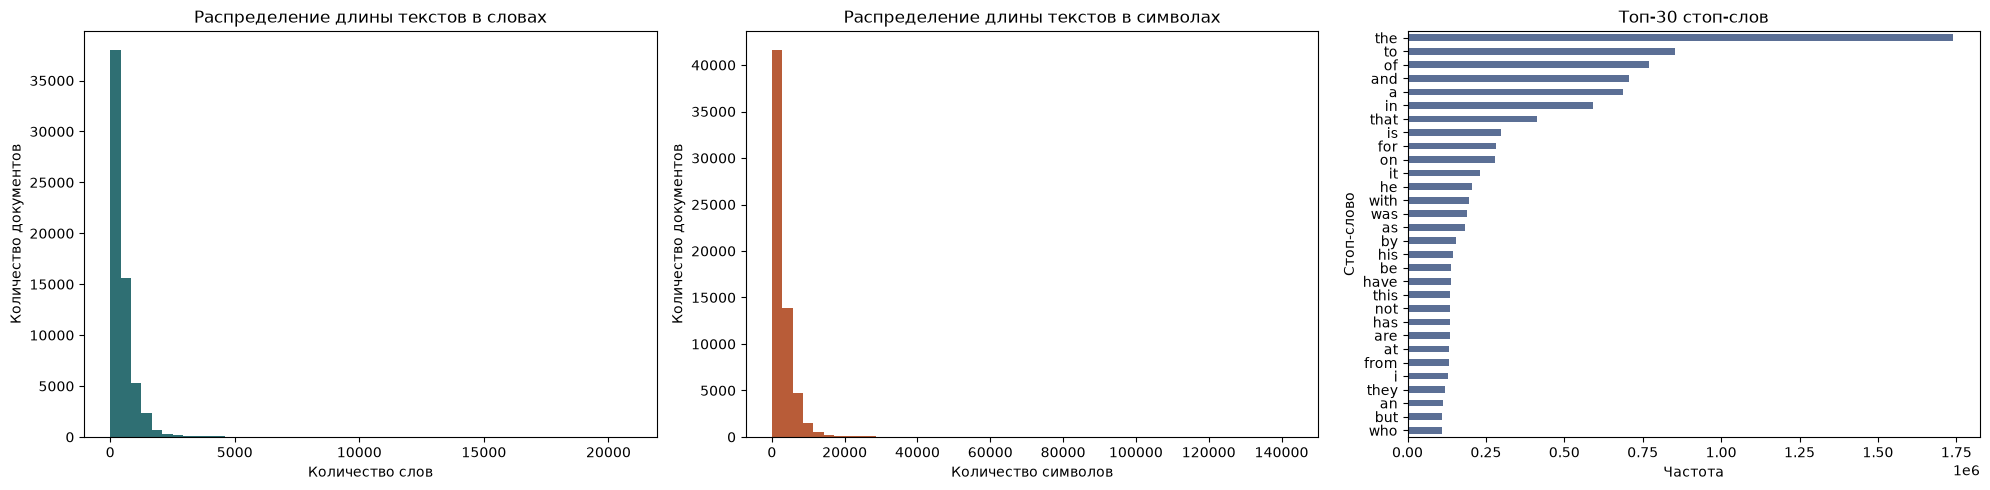

In [151]:
# Выделяем слова и оставляем только стоп-слова
words_df = processed_train_df["text"].str.lower().str.findall(r"\b[a-z]+\b").explode()
stop_words_df = words_df[words_df.isin(ENGLISH_STOP_WORDS)]
top_stop_words_df = stop_words_df.value_counts().head(30)

# Строим распределения длин текстов и частоты топ-30 стоп-слов
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(words_count, bins=50, color="#2f6f73")
axes[0].set_title("Распределение длины текстов в словах")
axes[0].set_xlabel("Количество слов")
axes[0].set_ylabel("Количество документов")

axes[1].hist(chars_count, bins=50, color="#b85c38")
axes[1].set_title("Распределение длины текстов в символах")
axes[1].set_xlabel("Количество символов")
axes[1].set_ylabel("Количество документов")

top_stop_words_df.sort_values().plot(kind="barh", ax=axes[2], color="#5b6f95")
axes[2].set_title("Топ-30 стоп-слов")
axes[2].set_xlabel("Частота")
axes[2].set_ylabel("Стоп-слово")

# Выводим графики
plt.tight_layout()
plt.show()

# 3. Типы специфического шума

Ищем следующие типы шума и заменяем их отдельными правилами:

| Тип шума | Замена |
|---|---|
| HTML-теги | `[HTML]` |
| HTML-сущности | `[HTML_ENTITY]` |
| URL-адреса | `[URL]` |
| Email-адреса | `[EMAIL]` |
| Упоминания `@username` | `[MENTION]` |
| Хештеги `#hashtag` | `[TAG]` |
| Числа | `[NUM]` |
| Повторная пунктуация | `[PUNCT]` |
| Лишние пробелы | один пробел |
| Нестандартные символы | `[SYM]` |

In [152]:
PUBLISHERS = [
    "Reuters",
    "Associated Press",
    "AP",
    "AFP",
    "Agence France-Presse",
    "New York Times",
    "NYTimes",
    "Washington Post",
    "Wall Street Journal",
    "WSJ",
    "CNN",
    "BBC",
    "Fox News",
    "NBC News",
    "CBS News",
    "ABC News",
    "The Guardian",
    "Bloomberg",
    "Politico",
    "USA Today",
    "HuffPost",
    "Xinhua",
    "Sputnik",
    "RT",
    "Russia Today",
    "TASS",
    "Breitbart",
    "Redflag Newsdesk",
    "Truth Broadcast Network",
    "EUvsDisinfo",
]


# Объединяем названия издателей в один безопасный паттерн.
PUBLISHER_REGEXES = [
    r"\b" + re.escape(name).replace(r"\ ", r"\s+") + r"\b"
    for name in sorted(PUBLISHERS, key=len, reverse=True)
]
PUBLISHER_COMBINED_REGEX = r"(?:" + "|".join(PUBLISHER_REGEXES) + r")"

# Распознаём поддерживаемые форматы дейтлайнов в начале новости.
DATELINE_COMBINED_REGEX = (
    rf"(?i)^\s*(?:"
    rf"[A-Z][A-Z\s.,'-]{{2,100}}\s*"
    rf"\(\s*{PUBLISHER_COMBINED_REGEX}\s*\)"
    rf"|"
    rf"[A-Z][A-Za-z\s.,'-]{{2,100}},?\s+"
    rf"[A-Za-z]{{3,9}}\s+\d{{1,2}}\s*"
    rf"\(\s*{PUBLISHER_COMBINED_REGEX}\s*\)"
    rf"|"
    rf"[A-Z][A-Za-z\s.,'-]{{2,100}},?\s*"
    rf"{PUBLISHER_COMBINED_REGEX}"
    rf"|"
    rf"By\s+{PUBLISHER_COMBINED_REGEX}"
    rf"|"
    rf"(?:Source|Copyright)\s*:?\s*{PUBLISHER_COMBINED_REGEX}"
    rf")\s*[-—–:,]?\s*"
)

# Объединяем контекстные упоминания издателя с общей заменой.
PUBLISHER_CONTEXT_REGEX = (
    rf"(?i)(?:"
    rf"\(\s*{PUBLISHER_COMBINED_REGEX}\s*\)"
    rf"|\b(?:Source|Copyright)\s*:?\s*{PUBLISHER_COMBINED_REGEX}"
    rf"|\bBy\s+{PUBLISHER_COMBINED_REGEX}"
    rf")"
)

In [153]:
# Описываем типы шума и будущие правила замены для конвейера очистки
noise_rules_df = pd.DataFrame(
    [
        ("Новостные дейтлайны", DATELINE_COMBINED_REGEX, "[DATELINE]"),
        ("Указание издателя", PUBLISHER_CONTEXT_REGEX, "[PUBLISHER]"),
        ("HTML-теги", r"<[^>]+>", "[HTML]"),
        ("HTML-сущности", r"&(?:[a-zA-Z]+|#[0-9]+|#x[0-9a-fA-F]+);", "[HTML_ENTITY]"),
        (
            "Email-адреса",
            r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
            "[EMAIL]",
        ),
        (
            "URL-адреса",
            r"(?:https?://|www\.)\S+|(?<![\w@])(?:[A-Za-z0-9-]+\.)+[a-z]{2,63}(?:/[^\s]*)?",
            "[URL]",
        ),
        ("Упоминания", r"(?<![\w.%+-])@[A-Za-z0-9_]+", "[MENTION]"),
        ("Хештеги", r"(?<!\w)#[A-Za-z0-9_]+", "[TAG]"),
        ("Числа", r"\d+(?:[.,]\d+)?", "[NUM]"),
        ("Повторная пунктуация", r"[!?.,]{2,}", "[PUNCT]"),
        ("Лишние пробелы", r"\s{2,}", " "),
        ("Нестандартные символы", r"[^\w\s.,!?;:'\"()\[\]{}%$€£-]", "[SYM]"),
    ],
    columns=["Тип шума", "Регулярное выражение", "Токен/действие"],
)

# Считаем, сколько документов и совпадений затрагивает каждый тип шума
noise_report_df = noise_rules_df.copy()
noise_report_df["Документов с шумом"] = [
    sum(bool(re.search(pattern, text)) for text in processed_train_df["text"])
    for pattern in noise_rules_df["Регулярное выражение"]
]
noise_report_df["Всего совпадений"] = [
    sum(len(re.findall(pattern, text)) for text in processed_train_df["text"])
    for pattern in noise_rules_df["Регулярное выражение"]
]
noise_report_df["Доля документов"] = (
    noise_report_df["Документов с шумом"] / len(processed_train_df["text"])
).round(4)

# Показываем короткие примеры найденного шума для проверки паттернов
noise_examples_df = pd.DataFrame(
    [
        (
            noise_type,
            [found for text in processed_train_df["text"] for found in re.findall(pattern, text)][:5],
        )
        for noise_type, pattern in noise_rules_df[
            ["Тип шума", "Регулярное выражение"]
        ].itertuples(index=False)
    ],
    columns=["Тип шума", "Примеры"],
)

# Выводим отчет по шуму, примеры и черновой preview будущего результата
display(noise_report_df.sort_values("Всего совпадений", ascending=False))
display(noise_examples_df)

,Тип шума,Регулярное выражение,Токен/действие,Документов с шумом,Всего совпадений,Доля документов
11,Нестандартные символы,"[^\w\s.,!?;:'\""()\[\]{}%$€£-]",[SYM],40009,915845,0.6364
10,Лишние пробелы,"\s{2,}",,49652,563266,0.7898
8,Числа,"\d+(?:[.,]\d+)?",[NUM],49054,435874,0.7802
6,Упоминания,(?<![\w.%+-])@[A-Za-z0-9_]+,[MENTION],7946,26834,0.1264
5,URL-адреса,(?:https?://|www\.)\S+|(?<![\w@])(?:[A-Za-z0-9...,[URL],8575,18491,0.1364
9,Повторная пунктуация,"[!?.,]{2,}",[PUNCT],7847,11989,0.1248
7,Хештеги,(?<!\w)#[A-Za-z0-9_]+,[TAG],3671,8891,0.0584
1,Указание издателя,(?i)(?:\(\s*(?:\bTruth\s+Broadcast\s+Network\b...,[PUBLISHER],2036,2316,0.0324
3,HTML-сущности,&(?:[a-zA-Z]+|#[0-9]+|#x[0-9a-fA-F]+);,[HTML_ENTITY],525,2253,0.0084
2,HTML-теги,<[^>]+>,[HTML],169,1488,0.0027


,Тип шума,Примеры
0,Новостные дейтлайны,"[Day in and day out, CNN , Share on Twitter \n..."
1,Указание издателя,"[(AP), by Fox News, by Breitbart, Source: CNN,..."
2,HTML-теги,"[<![CDATA[ (function(d, s, id) { var js, fjs ..."
3,HTML-сущности,"[&#038;, &nbsp;, &nbsp;, &nbsp;, &nbsp;]"
4,Email-адреса,"[tony.cervone@gm.comor, julie.huston-rough@gm...."
5,URL-адреса,[https://twitter.com/P0TUSTrump/status/7737242...
6,Упоминания,"[@PrisonPlanet, @PrisonPlanet, @BlackManTrump,..."
7,Хештеги,"[#NBCNewsForum, #HillarysEarPiece, #N, #038, #..."
8,Числа,"[300,000, 354,360, 0, 773724216247984129, 4]"
9,Повторная пунктуация,"[.,, .,, .,, ..., .,]"


# 4. Комплексный конвейер очистки текста

Конвейер очистки текста, где каждый тип шума обрабатывается своим правилом (например, URL-адреса заменяются на специальный токен `[URL]`, а числа - на токен `[NUM]`). На выходе конвейера добавляется к каждому документу технические токены начала и конца последовательности: `<s>` и `</s>`.

In [163]:
def clean_text_df(data_df: pd.DataFrame) -> pd.DataFrame:
    """
    Очищает текстовую колонку датафрейма по правилам noise_rules_df.

    Parameters:
        data_df (pd.DataFrame): Датафрейм с колонкой text.

    Returns:
        pd.DataFrame: Копия датафрейма с очищенной колонкой text.

    Fallbacks:
        Пропуски в колонке text заменяются пустыми строками.
    """
    # Копируем данные и приводим тексты к строковому представлению
    clean_data_df = data_df.copy()
    clean_data_df["text"] = clean_data_df["text"].fillna("").astype(str)

    # Последовательно применяем отдельный паттерн для каждого типа шума
    for noise_type, pattern, replacement in noise_rules_df.itertuples(index=False):
        clean_data_df["text"] = clean_data_df["text"].str.replace(
            pattern, replacement + " ", regex=True
        )

    # Нормализуем пробелы и добавляем границы последовательности
    clean_data_df["text"] = (
        clean_data_df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
    )
    clean_data_df["text"] = "<s> " + clean_data_df["text"] + " </s>"
    return clean_data_df


# Очищаем выборки
processed_train_df = clean_text_df(processed_train_df)

In [164]:
# Демонстрируем результат работы функции очистки на первых документах
display(
    pd.DataFrame(
        {
            "Исходный текст": train_df["text"].head(5),
            "Очищенный текст": processed_train_df["text"].head(5),
        }
    )
)

,Исходный текст,Очищенный текст
18651,Police will remove people from Catalan indepen...,<s> Police will remove people from Catalan ind...
54374,She never does things the way the rest of us d...,<s> She never does things the way the rest of ...
27697,In a move that left many veterans groups breat...,<s> In a move that left many veterans groups b...
57425,"Day in and day out, CNN works hard to try and ...",<s> [DATELINE] works hard to try and convince ...
45997,The woman who wants to be the next Democrat ca...,<s> The woman who wants to be the next Democra...


**Текст 1**:

```text
She never does things the way the rest of us do. She s always got an angle she s always got a way around doing things the way the  everyday people  she claims she represents do them. How can any female  say that lying, cheating and conniving Hillary is a  role model  for woman with a straight face? Crooked  Hillary Clinton wore an ear piece in last night s Commander in Chief Forum hosted by NBC and MSNBC. This was the first event where both Donald Trump and Hillary Clinton were invited to attend together. Each candidate received a short period with host Matt Lauer. It was expected that both candidates would provide unaided answers to the questions asked but it appears Hillary did not.Donald Trump tweeted after the event his disdain for candidate Clinton using the ear piece which provided her a boost in answering questions. Trump tweeted  We can t let Hillary get away with wearing an ear piece during tonight s Veteran Forum .https://twitter.com/P0TUSTrump/status/773724216247984129Trump s not the only one who noticed:My article is the top fat link on Drudge. Nice. https://t.co/mw4f4s1xot pic.twitter.com/jiamqzVV33  Paul Joseph Watson (@PrisonPlanet) September 8, 2016Others noted her cheating ways as well accusing Hillary of eye movements and gaps between speech that showed she was listening and not thinking  My article is the top fat link on Drudge. Nice. https://t.co/mw4f4s1xot pic.twitter.com/jiamqzVV33  Paul Joseph Watson (@PrisonPlanet) September 8, 2016https://twitter.com/AltStreamMedia/status/773732560824180736bocavista2016: RT BlkMan4Trump: #NBCNewsForum I think we all know who was on the other end of #HillarysEarPiece pic.twitter.com/XqjIbMd5It #N  TrumpIsBlackLikeMe (@BlackManTrump) September 8, 2016Actor James Woods asks reminds us of Wikileaks email from Huma to Hillary regarding her  earpiece :pic.twitter.com/T3gpMPelJl  James Woods (@RealJamesWoods) September 8, 2016Cheating like this is not totally unexpected. President Obama was accused of doing the same thing in the debates in 2012 with candidate Romney and some have warned that this may happen again a few weeks ago. The picture of the wireless earpiece above is similar to one Obama may have used during those debates. As noted by thetruthdivision.com if you go back and watch the second and third debates in 2012, examine Obama s mannerism and head movements while he was watching Mitt Romney speak.Via: The Truth Division  h/t GP

<s> She never does things the way the rest of us do. She s always got an angle she s always got a way around doing things the way the everyday people she claims she represents do them. How can any female say that lying, cheating and conniving Hillary is a role model for woman with a straight face? Crooked Hillary Clinton wore an ear piece in last night s Commander in Chief Forum hosted by NBC and MSNBC. This was the first event where both Donald Trump and Hillary Clinton were invited to attend together. Each candidate received a short period with host Matt Lauer. It was expected that both candidates would provide unaided answers to the questions asked but it appears Hillary did not.Donald Trump tweeted after the event his disdain for candidate Clinton using the ear piece which provided her a boost in answering questions. Trump tweeted We can t let Hillary get away with wearing an ear piece during tonight s Veteran Forum .[URL] s not the only one who noticed:My article is the top fat link on Drudge. Nice. [URL] [URL] Paul Joseph Watson ([MENTION] ) September [NUM] , [NUM] Others noted her cheating ways as well accusing Hillary of eye movements and gaps between speech that showed she was listening and not thinking My article is the top fat link on Drudge. Nice. [URL] [URL] Paul Joseph Watson ([MENTION] ) September [NUM] , [NUM] [URL] RT BlkMan[NUM] Trump: [TAG] I think we all know who was on the other end of [TAG] [URL] [TAG] TrumpIsBlackLikeMe ([MENTION] ) September [NUM] , [NUM] Actor James Woods asks reminds us of Wikileaks email from Huma to Hillary regarding her earpiece :[URL] James Woods ([MENTION] ) September [NUM] , [NUM] Cheating like this is not totally unexpected. President Obama was accused of doing the same thing in the debates in [NUM] with candidate Romney and some have warned that this may happen again a few weeks ago. The picture of the wireless earpiece above is similar to one Obama may have used during those debates. As noted by [URL] if you go back and watch the second and third debates in [NUM] , examine Obama s mannerism and head movements while he was watching Mitt Romney speak.Via: The Truth Division h[SYM] t GP </s>
```

**Текст 2**:

```text
Day in and day out, CNN works hard to try and convince American audiences that it s a legitimate news outlet, and it hopes that the public will take seriously the troubled news network s various on-screen actors and quasi-journalists. On New Year s Eve, one of CNN s highly paid anchors, Don Lemon could be seen on national TV in New Orleans with co-presenter Brooke Baldwin, as Lemon proceeded to pound shots of tequila live on air, slurring his speech and shouting, while simultaneously getting his ear pierced during the program. Lemon then went on to sink into a melancholy diatribe about not being in a relationship (Lemon is gay) and personal struggles with his own narcissism.The episode prompted many critics to question his psychological state, and also to ask whether or not Lemon might have a serious drinking or substance problem.Things got so bad that network producers had to pull the audio feed while drunk Lemon began shouting  2016 was awful. On the New York City feed, onlookers from CNN were obscure female American comedian, Kathy Griffin, joined by  news presenter  and actor Anderson Cooper, both of whom were enjoying the spectacle   not at all concerned with the potential damage to Lemon s reputation as a result of his alcoholic episode on air.Griffin could be seen shouting,  Nipples! Nipples! Nipples!  as Lemon began to unbutton his dress shirt.Watch Don Lemon drunk on air during CNN s New Years broadcast:https://www.youtube.com/watch?v=LNWx-ZfrKOU .

<s> [DATELINE] works hard to try and convince American audiences that it s a legitimate news outlet, and it hopes that the public will take seriously the troubled news network s various on-screen actors and quasi-journalists. On New Year s Eve, one of CNN s highly paid anchors, Don Lemon could be seen on national TV in New Orleans with co-presenter Brooke Baldwin, as Lemon proceeded to pound shots of tequila live on air, slurring his speech and shouting, while simultaneously getting his ear pierced during the program. Lemon then went on to sink into a melancholy diatribe about not being in a relationship (Lemon is gay) and personal struggles with his own narcissism.The episode prompted many critics to question his psychological state, and also to ask whether or not Lemon might have a serious drinking or substance problem.Things got so bad that network producers had to pull the audio feed while drunk Lemon began shouting [NUM] was awful. On the New York City feed, onlookers from CNN were obscure female American comedian, Kathy Griffin, joined by news presenter and actor Anderson Cooper, both of whom were enjoying the spectacle not at all concerned with the potential damage to Lemon s reputation as a result of his alcoholic episode on air.Griffin could be seen shouting, Nipples! Nipples! Nipples! as Lemon began to unbutton his dress shirt.Watch Don Lemon drunk on air during CNN s New Years broadcast:[URL] . </s>
```

# 5. Сравнительная нормализация: Стемминг и Лемматизация

Сравнительная нормализация между двумя способами: стемминг и лемматизация.

Сравнивается размер полученных словарей (количества уникальных токенов) до и после каждого вида нормализации.

Выводы о применимости каждого метода для вашего типа текстов.

In [166]:
def normalize_processed_text_df(processed_data_df: pd.DataFrame) -> pd.DataFrame:
    normalized_data_df = processed_data_df.copy()
    for _, _, replacement in noise_rules_df.itertuples(index=False):
        if replacement == " ":
            continue

        if replacement in ["[PUBLISHER]", "[DATELINE]"]:
            normalized_data_df["text"] = normalized_data_df["text"].str.replace(
                replacement, "publisher"
            )
            continue

        normalized_data_df["text"] = normalized_data_df["text"].str.replace(
            replacement, ""
        )

    normalized_data_df["text"] = normalized_data_df["text"].replace(r'[^a-zA-Zа-яА-ЯёЁ\s]', '', regex=True)
    normalized_data_df["text"] = normalized_data_df["text"].str[2:-3]
    normalized_data_df["text"] = (
        normalized_data_df["text"].str.replace(r"\s+", " ", regex=True).str.strip().str.lower()
    )
    return normalized_data_df

    
normalized_train_df = normalize_processed_text_df(processed_train_df)
normalized_train_df.head(5)

,text,target
18651,police will remove people from catalan indepen...,1
54374,she never does things the way the rest of us d...,0
27697,in a move that left many veterans groups breat...,1
57425,publisher works hard to try and convince ameri...,0
45997,the woman who wants to be the next democrat ca...,0


**Текст 1**:

```text
She never does things the way the rest of us do. She s always got an angle she s always got a way around doing things the way the  everyday people  she claims she represents do them. How can any female  say that lying, cheating and conniving Hillary is a  role model  for woman with a straight face? Crooked  Hillary Clinton wore an ear piece in last night s Commander in Chief Forum hosted by NBC and MSNBC. This was the first event where both Donald Trump and Hillary Clinton were invited to attend together. Each candidate received a short period with host Matt Lauer. It was expected that both candidates would provide unaided answers to the questions asked but it appears Hillary did not.Donald Trump tweeted after the event his disdain for candidate Clinton using the ear piece which provided her a boost in answering questions. Trump tweeted  We can t let Hillary get away with wearing an ear piece during tonight s Veteran Forum .https://twitter.com/P0TUSTrump/status/773724216247984129Trump s not the only one who noticed:My article is the top fat link on Drudge. Nice. https://t.co/mw4f4s1xot pic.twitter.com/jiamqzVV33  Paul Joseph Watson (@PrisonPlanet) September 8, 2016Others noted her cheating ways as well accusing Hillary of eye movements and gaps between speech that showed she was listening and not thinking  My article is the top fat link on Drudge. Nice. https://t.co/mw4f4s1xot pic.twitter.com/jiamqzVV33  Paul Joseph Watson (@PrisonPlanet) September 8, 2016https://twitter.com/AltStreamMedia/status/773732560824180736bocavista2016: RT BlkMan4Trump: #NBCNewsForum I think we all know who was on the other end of #HillarysEarPiece pic.twitter.com/XqjIbMd5It #N  TrumpIsBlackLikeMe (@BlackManTrump) September 8, 2016Actor James Woods asks reminds us of Wikileaks email from Huma to Hillary regarding her  earpiece :pic.twitter.com/T3gpMPelJl  James Woods (@RealJamesWoods) September 8, 2016Cheating like this is not totally unexpected. President Obama was accused of doing the same thing in the debates in 2012 with candidate Romney and some have warned that this may happen again a few weeks ago. The picture of the wireless earpiece above is similar to one Obama may have used during those debates. As noted by thetruthdivision.com if you go back and watch the second and third debates in 2012, examine Obama s mannerism and head movements while he was watching Mitt Romney speak.Via: The Truth Division  h/t GP

she never does things the way the rest of us do she s always got an angle she s always got a way around doing things the way the everyday people she claims she represents do them how can any female say that lying cheating and conniving hillary is a role model for woman with a straight face crooked hillary clinton wore an ear piece in last night s commander in chief forum hosted by nbc and msnbc this was the first event where both donald trump and hillary clinton were invited to attend together each candidate received a short period with host matt lauer it was expected that both candidates would provide unaided answers to the questions asked but it appears hillary did notdonald trump tweeted after the event his disdain for candidate clinton using the ear piece which provided her a boost in answering questions trump tweeted we can t let hillary get away with wearing an ear piece during tonight s veteran forum s not the only one who noticedmy article is the top fat link on drudge nice paul joseph watson september others noted her cheating ways as well accusing hillary of eye movements and gaps between speech that showed she was listening and not thinking my article is the top fat link on drudge nice paul joseph watson september rt blkman trump i think we all know who was on the other end of trumpisblacklikeme september actor james woods asks reminds us of wikileaks email from huma to hillary regarding her earpiece james woods september cheating like this is not totally unexpected president obama was accused of doing the same thing in the debates in with candidate romney and some have warned that this may happen again a few weeks ago the picture of the wireless earpiece above is similar to one obama may have used during those debates as noted by if you go back and watch the second and third debates in examine obama s mannerism and head movements while he was watching mitt romney speakvia the truth division h t g
```

**Текст 2**:

```text
Day in and day out, CNN works hard to try and convince American audiences that it s a legitimate news outlet, and it hopes that the public will take seriously the troubled news network s various on-screen actors and quasi-journalists. On New Year s Eve, one of CNN s highly paid anchors, Don Lemon could be seen on national TV in New Orleans with co-presenter Brooke Baldwin, as Lemon proceeded to pound shots of tequila live on air, slurring his speech and shouting, while simultaneously getting his ear pierced during the program. Lemon then went on to sink into a melancholy diatribe about not being in a relationship (Lemon is gay) and personal struggles with his own narcissism.The episode prompted many critics to question his psychological state, and also to ask whether or not Lemon might have a serious drinking or substance problem.Things got so bad that network producers had to pull the audio feed while drunk Lemon began shouting  2016 was awful. On the New York City feed, onlookers from CNN were obscure female American comedian, Kathy Griffin, joined by  news presenter  and actor Anderson Cooper, both of whom were enjoying the spectacle   not at all concerned with the potential damage to Lemon s reputation as a result of his alcoholic episode on air.Griffin could be seen shouting,  Nipples! Nipples! Nipples!  as Lemon began to unbutton his dress shirt.Watch Don Lemon drunk on air during CNN s New Years broadcast:https://www.youtube.com/watch?v=LNWx-ZfrKOU .

publisher works hard to try and convince american audiences that it s a legitimate news outlet and it hopes that the public will take seriously the troubled news network s various onscreen actors and quasijournalists on new year s eve one of cnn s highly paid anchors don lemon could be seen on national tv in new orleans with copresenter brooke baldwin as lemon proceeded to pound shots of tequila live on air slurring his speech and shouting while simultaneously getting his ear pierced during the program lemon then went on to sink into a melancholy diatribe about not being in a relationship lemon is gay and personal struggles with his own narcissismthe episode prompted many critics to question his psychological state and also to ask whether or not lemon might have a serious drinking or substance problemthings got so bad that network producers had to pull the audio feed while drunk lemon began shouting was awful on the new york city feed onlookers from cnn were obscure female american comedian kathy griffin joined by news presenter and actor anderson cooper both of whom were enjoying the spectacle not at all concerned with the potential damage to lemon s reputation as a result of his alcoholic episode on airgriffin could be seen shouting nipples nipples nipples as lemon began to unbutton his dress shirtwatch don lemon drunk on air during cnn s new years broadcast
```

In [174]:
# Оставляем слова
normalized_words_df = normalized_train_df["text"].str.findall(r"\b[a-z]+\b").explode().dropna()

# Считаем исходный словарь до нормализации
vocab_before = set(normalized_words_df)

# Применяем стемминг как отдельный способ нормализации
stemmer = PorterStemmer()
stemmed_vocab = {stemmer.stem(word) for word in vocab_before}

# Применяем лемматизацию как отдельный способ нормализации
lemmatizer = WordNetLemmatizer()
lemmatized_vocab = {lemmatizer.lemmatize(word) for word in vocab_before}

# Выводим размеры словарей до и после каждого способа нормализации
normalization_vocab_sizes_df = pd.DataFrame(
    [
        ("Стемминг", len(vocab_before), len(stemmed_vocab)),
        ("Лемматизация", len(vocab_before), len(lemmatized_vocab)),
    ],
    columns=["Тип нормализации", "Размер словаря до", "Размер словаря после"],
)
normalization_vocab_sizes_df["Сокращение словаря"] = (
    normalization_vocab_sizes_df["Размер словаря до"]
    - normalization_vocab_sizes_df["Размер словаря после"]
)
normalization_vocab_sizes_df["Сокращение, %"] = (
    normalization_vocab_sizes_df["Сокращение словаря"]
    / normalization_vocab_sizes_df["Размер словаря до"]
    * 100
).round(2)

display(normalization_vocab_sizes_df)

,Тип нормализации,Размер словаря до,Размер словаря после,Сокращение словаря,"Сокращение, %"
0,Стемминг,262804,217780,45024,17.13
1,Лемматизация,262804,250356,12448,4.74


In [ ]:
# Предобработка тестовой выборки
test_df = test_df.dropna()
clean_test_df = clean_text_df(test_df)